# 19 - K-Means Clustering

Implement K-Means clustering on a dataset with two features.

**Problem Statement**

Cluster a 2D dataset using K-Means and evaluate cluster quality.

**Understanding of Dataset**

We use a sample CSV containing two numeric features (x1, x2). The notebook generates a sample CSV (`kmeans_sample.csv`) and reads it as the input to simulate exam conditions where you'll get a CSV.

**Theory**

K-Means partitions data into `k` clusters by minimizing within-cluster sum of squares. It alternates between assigning points to the nearest centroid and updating centroids to the mean of assigned points.

**Mathematical Representation**

Objective: minimize inertia = sum_i ||x_i - mu_{c(i)}||^2 where `mu_j` is centroid of cluster j and c(i) is cluster assignment.

**Diagram**

We'll visualize clusters and centroids on a 2D scatter plot.

**Pseudocode**

1. Load CSV with two features
2. Clean data (drop/handle missing)
3. Scale features (StandardScaler)
4. Use elbow method / silhouette to pick `k`
5. Fit KMeans and predict clusters
6. Plot clusters and compute silhouette score / inertia

**Expected Output**

- Scatter plot showing distinct clusters and centroids.
- Numeric values: chosen `k`, inertia, silhouette score.

**Obtained Output**

Will be shown after running the code cells below: plots and printed metrics.

In [1]:
# Imports and dataset creation (we save a CSV and read it back to simulate exam CSV input)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Generate a simple 2-feature dataset and save to CSV (this acts as the sample CSV you'll replace in exams)
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42, n_features=2)
df = pd.DataFrame(X, columns=['x1','x2'])
df.to_csv('kmeans_sample.csv', index=False)
print('Sample CSV saved as kmeans_sample.csv (columns: x1, x2)')

Sample CSV saved as kmeans_sample.csv (columns: x1, x2)


In [2]:
# === Data loading & cleaning ===
# Read CSV (in exam, replace filename with the provided CSV path)
data = pd.read_csv('kmeans_sample.csv')
# If your exam CSV has a header different from x1,x2, rename accordingly.
# Example: data.columns = ['feature1', 'feature2']

# Quick cleaning: check missing values and drop if any (simple strategy)
print('Shape before cleaning:', data.shape)
print('Missing values per column:', data.isnull().sum())
data = data.dropna().reset_index(drop=True)
print('Shape after cleaning:', data.shape)
data.head()

Shape before cleaning: (300, 2)
Missing values per column: x1    0
x2    0
dtype: int64
Shape after cleaning: (300, 2)


,x1,x2
0,-9.297689,6.473679
1,-9.698741,6.938967
2,-1.686653,7.793442
3,-7.097308,-5.781333
4,-10.876452,6.315437


In [3]:
# === Explaining the data ===
print('Data info:')
print(data.info())
print('Descriptive statistics:')
print(data.describe())

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      300 non-null    float64
 1   x2      300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB
None
Descriptive statistics:
               x1          x2
count  300.000000  300.000000
mean    -3.403837    2.845329
std      5.289154    6.225742
min    -11.309972   -8.919342
25%     -7.952236   -1.181119
50%     -4.708134    5.066995
75%     -0.117606    8.079443
max      6.954537   11.477528


In [4]:
# === Feature scaling ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[['x1','x2']])
# Keep as DataFrame for convenience
Xs = pd.DataFrame(X_scaled, columns=['x1_s','x2_s'])
Xs.head()

,x1_s,x2_s
0,-1.116190,0.583772
1,-1.192142,0.658633
2,0.325204,0.796111
3,-0.699477,-1.387959
4,-1.415179,0.558312


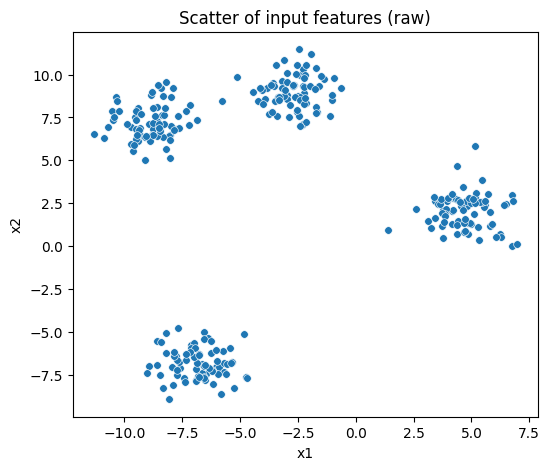

In [5]:
# === EDA ===
plt.figure(figsize=(6,5))
sns.scatterplot(x='x1', y='x2', data=data, s=30)
plt.title('Scatter of input features (raw)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [6]:
# === Feature engineering ===
# For a simple 2-feature clustering task, we usually don't need extra features.
# If desired, you could add polynomial combinations or distances, but we'll keep it simple.

# Example placeholder (uncomment if needed):
# Xs['x1_x2'] = Xs['x1_s'] * Xs['x2_s']
Xs.shape

(300, 2)

C:\Users\paritosh\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\paritosh\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Program Files\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Lib\subprocess.py", line 1036, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~

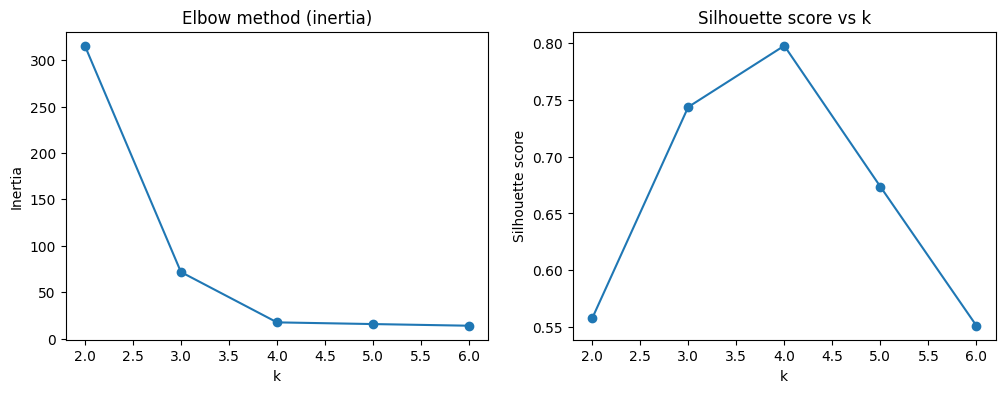

Inertias: [315.4925376247822, 71.68831894273329, 17.466197609060576, 15.638657879395389, 13.852405489607472]
Silhouette scores: [0.55773379731114, 0.743594601645247, 0.797473988963273, 0.6735935695194377, 0.5513465668253311]


In [7]:
# === Choose k: elbow + silhouette quick check ===
inertias = []
sil_scores = []
K_range = range(2,7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Xs)
    inertias.append(km.inertia_)
    # silhouette requires k>1 and less than n_samples
    sil = silhouette_score(Xs, km.labels_)
    sil_scores.append(sil)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(list(K_range), inertias, '-o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method (inertia)')

plt.subplot(1,2,2)
plt.plot(list(K_range), sil_scores, '-o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette score vs k')
plt.show()

print('Inertias:', inertias)
print('Silhouette scores:', sil_scores)

Chosen k: 4
Inertia: 17.466197609060576
Silhouette score: 0.797473988963273


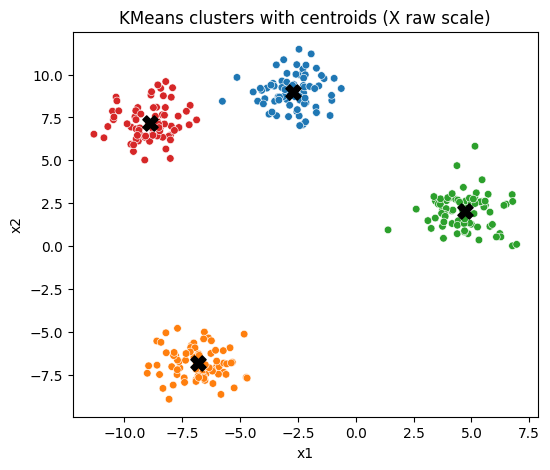

In [8]:
# === Fit final KMeans (choose k=4 based on generation) ===
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels = kmeans.fit_predict(Xs)
centers = kmeans.cluster_centers_
inertia = kmeans.inertia_
sil = silhouette_score(Xs, labels)

print(f'Chosen k: {k_final}')
print('Inertia:', inertia)
print('Silhouette score:', sil)

# Plot clusters in original feature space (unscaled for easier interpretation)
plt.figure(figsize=(6,5))
# Map labels to colors
palette = sns.color_palette('tab10', k_final)
sns.scatterplot(x=data['x1'], y=data['x2'], hue=labels, palette=palette, legend=False, s=30)
# Transform centers back to original scale for plotting
centers_orig = scaler.inverse_transform(centers)
plt.scatter(centers_orig[:,0], centers_orig[:,1], c='black', s=120, marker='X')
plt.title('KMeans clusters with centroids (X raw scale)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [9]:
# === Evaluation matrix (summary) ===
results = {
    'k': k_final,
    'inertia': float(inertia),
    'silhouette': float(sil)
}
print('Results summary:', results)

# Save cluster assignments to CSV so you can inspect clusters later
out = data.copy()
out['cluster'] = labels
out.to_csv('kmeans_result_with_clusters.csv', index=False)
print('Saved results to kmeans_result_with_clusters.csv')

Results summary: {'k': 4, 'inertia': 17.466197609060576, 'silhouette': 0.797473988963273}
Saved results to kmeans_result_with_clusters.csv


**Notes for using a different CSV (exam conditions)**

- Replace the `pd.read_csv('kmeans_sample.csv')` line with the provided CSV filename.
- If column names differ, rename columns to two numeric feature names, e.g. `data.columns = ['x1','x2']`.
- If there are categorical features, drop or encode them before clustering.
- If you expect different scale, leave scaling step as-is (StandardScaler) to normalize features.

**What I did (concise)**

- Created a simple 2D CSV, read it, cleaned missing values, scaled features, used elbow/silhouette to pick `k`, fit K-Means, visualized clusters, and saved results.